In [1]:
!pip install onnx
!pip install onnxscript

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim

from torch.nn.utils.fusion import fuse_conv_bn_eval

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import onnx

import matplotlib.pyplot as plt
import numpy as np

from datetime import datetime
from time import time
import copy

# L1 Norm

In [3]:
def compute_l1_norm(model):
  l1 = 0
  for name, param in model.named_parameters():
    # Check if the parameter name contains 'weight' and does NOT contain 'bias'
    # The 'weight' check is often redundant if you skip 'bias', but good practice.
    # The key is to check for 'bias' in the name and skip it.
    if 'bias' not in name:
      l1 += torch.sum(torch.abs(param))

  return l1

# Data Loaders

In [4]:
def get_loaders(batch_size=64, num_workers=2, normalize=True):
    # Statistiche CIFAR-10 standard
    mean = (0.4914, 0.4822, 0.4465)
    std  = (0.2470, 0.2435, 0.2616)

    if normalize:
      train_tf = transforms.Compose([
          transforms.RandomCrop(32, padding=4),       # augmentation fondamentale
          transforms.RandomHorizontalFlip(),
          transforms.ToTensor(),
          transforms.Normalize(mean, std),
      ])
      test_tf = transforms.Compose([
          transforms.ToTensor(),
          transforms.Normalize(mean, std),
      ])
    else:
      train_tf = transforms.Compose([
          transforms.RandomCrop(32, padding=4),       # augmentation fondamentale
          transforms.RandomHorizontalFlip(),
          transforms.ToTensor(),
      ])
      test_tf = transforms.Compose([
          transforms.ToTensor(),
      ])

    train_ds = datasets.CIFAR10(root="./data", train=True,  download=True, transform=train_tf)
    test_ds  = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_tf)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    return train_loader, test_loader

# Training Code

In [5]:
def train_one_epoch(model, loader, optimizer, criterion, device, l1_weight=0):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)

        if l1_weight > 0:
          l1_reg = compute_l1_norm(model)
          loss += l1_weight * l1_reg

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total

In [6]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss   = criterion(logits, labels)

        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total

In [7]:
def training_loop(model, train_loader, test_loader, epochs=100, batch_size=128, lr=1e-3, l1_weight=0, torch_path="best_model.pth"):
    DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
    
    print(f"Device: {DEVICE}")
    model = model.to(DEVICE)
    
    train_loader, test_loader = get_loaders(batch_size=batch_size)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Cosine annealing: abbassa lr dolcemente fino a quasi 0
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    # Conta parametri
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Parameters: {n_params:,}\n")
    
    train_losses = []
    test_losses  = []
    best_acc = 0.0
    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, l1_weight=l1_weight)
        test_loss,  test_acc  = evaluate(model, test_loader, criterion, DEVICE)
        scheduler.step()

        if l1_weight > 0:
            l1_reg = compute_l1_norm(model)
            print(f"L1: {l1_reg.item()}")
    
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), torch_path)
    
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"train loss {train_loss:.3f} acc {train_acc*100:.1f}% | "
              f"test loss {test_loss:.3f} acc {test_acc*100:.1f}% | "
              f"best {best_acc*100:.1f}%")
        train_losses.append(train_loss)
        test_losses.append(test_loss)
    
    print(f"\nBest test accuracy: {best_acc*100:.2f}%")

    return model, train_losses, test_losses

# Architecture

In [8]:
# with batch norm before activation function
def make_cnn_tiny(in_ch, in_dim, width=16, linear_size=256, act_fun=nn.GELU, act_kwargs={}):
    model = nn.Sequential(
        nn.Conv2d(in_ch, width, 3, stride=2, padding=1),
        nn.BatchNorm2d(width),
        act_fun(**act_kwargs),
        nn.Conv2d(width, 2*width, 3, stride=2, padding=1),
        nn.BatchNorm2d(2*width),
        act_fun(**act_kwargs),
        nn.Conv2d(2*width, 4*width, 3, stride=2, padding=1),
        nn.BatchNorm2d(4 * width),
        act_fun(),
        nn.Flatten(),
        nn.Linear((in_dim//8) * (in_dim//8) * 4 * width, linear_size),
        act_fun(**act_kwargs),
        nn.Linear(linear_size,10)
    )
    return model

# Batch Norm Fusion

In [9]:
def fuse_bn_recursively_sequential(model, layers=None):
    if layers is None:
        layers = []
    
    # We need to look ahead or keep track of the previous conv
    it = list(model.named_children())
    i = 0
    while i < len(it):
        name, child = it[i]
        
        # Check for Conv-BN pair
        if isinstance(child, nn.Conv2d) and (i + 1 < len(it)) and isinstance(it[i+1][1], nn.BatchNorm2d):
            print(f"Fusing {it[i+1][0]} into {name}")
            fused_conv = fuse_conv_bn_eval(child, it[i+1][1])
            layers.append(fused_conv)
            i += 2  # Skip both the Conv and the BN
        
        elif len(list(child.children())) > 0:
            # Recurse without re-wrapping in Sequential yet
            fuse_bn_recursively_sequential(child, layers)
            i += 1
            
        else:
            # It's a standalone layer (GELU, Linear, Flatten, or a BN with no Conv)
            layers.append(child)
            i += 1
            
    return nn.Sequential(*layers)

# Usage:
# model_seq = fuse_bn_recursively_sequential(model_norm)

In [10]:
def get_normalization_layer(mean, std):
  # CIFAR-10 means/stds
  mean = torch.tensor(mean)
  std = torch.tensor(std)
  
  # Create a BN layer
  norm_layer = nn.BatchNorm2d(3)
  
  # Set parameters
  norm_layer.running_mean.copy_(mean)
  norm_layer.running_var.copy_(std**2) # BN uses variance
  norm_layer.weight.data.fill_(1.0)
  norm_layer.bias.data.fill_(0.0)
  norm_layer.eps = 1e-12 # Minimal epsilon for stability
  
  norm_layer.eval() # Vital: lock it so it doesn't update
  return norm_layer

In [11]:
def add_kernel_shape_attribute(onnx_path):
    model = onnx.load(onnx_path)
    
    for node in model.graph.node:
        if node.op_type == "Conv":
            has_kernel = any(attr.name == "kernel_shape" for attr in node.attribute)
            if not has_kernel:
                # find weight tensor
                weight_name = node.input[1]
                for init in model.graph.initializer:
                    if init.name == weight_name:
                        shape = init.dims
                        kernel_shape = shape[2:]  # (kH, kW)
    
                        attr = onnx.helper.make_attribute("kernel_shape", kernel_shape)
                        node.attribute.append(attr)
    
    model = onnx.shape_inference.infer_shapes(model)
    onnx.save(model, onnx_path)

In [12]:
def export_onnx(model, onnx_path, mean=None, std=None):
    if mean is None:
        mean = (0.4914, 0.4822, 0.4465)
    if std is None:
        std  = (0.2470, 0.2435, 0.2616)

    model.eval()
    model_norm = nn.Sequential(get_normalization_layer(mean, std), model)
    model_seq = fuse_bn_recursively_sequential(model_norm)

    dummy_input = torch.randn(1, 3, 32, 32)
    
    torch.onnx.export(
        model_seq.to('cpu'),
        dummy_input,
        onnx_path,
        export_params=True,       # Store the trained parameter weights inside the model file
        opset_version=20,          # The ONNX version to export to
        do_constant_folding=True,  # Whether to execute constant folding for optimization
        input_names=['input'],     # The model's input names
        output_names=['output'],    # The model's output names
        external_data=False
    )

    # sometimes, conv nodes get saved without kernel_shape attribute, but onnx2pytorch
    # requires that attribute for correct parsing, so add it manually and save it back to file
    add_kernel_shape_attribute(onnx_path)
    
    print(f"Model successfully exported to {onnx_path}")

# Training Runs

## Width 8 Standard

In [15]:
EPOCHS     = 120
BATCH_SIZE = 128
LR         = 1e-3
WIDTH      = 8
l1_weight  = 0.
torch_path = f"best_model_bn_{WIDTH}.pth"
onnx_path  = f"best_model_bn_{WIDTH}.onnx"
model      = make_cnn_tiny(3, 32, width=WIDTH, linear_size=256, act_fun=nn.GELU)
train_loader, test_loader = get_loaders(batch_size=BATCH_SIZE)

model, train_losses, test_losses = training_loop(model, train_loader, test_loader, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, l1_weight=l1_weight, torch_path=torch_path)

export_onnx(model, onnx_path)

Device: cuda
Parameters: 140,042

Epoch   1/120 | train loss 1.638 acc 40.1% | test loss 1.392 acc 49.2% | best 49.2%
Epoch   2/120 | train loss 1.402 acc 49.1% | test loss 1.283 acc 53.6% | best 53.6%
Epoch   3/120 | train loss 1.303 acc 52.8% | test loss 1.194 acc 57.2% | best 57.2%
Epoch   4/120 | train loss 1.237 acc 55.5% | test loss 1.176 acc 58.3% | best 58.3%
Epoch   5/120 | train loss 1.179 acc 57.7% | test loss 1.142 acc 59.6% | best 59.6%
Epoch   6/120 | train loss 1.139 acc 59.0% | test loss 1.059 acc 62.0% | best 62.0%
Epoch   7/120 | train loss 1.099 acc 60.7% | test loss 1.038 acc 63.1% | best 63.1%
Epoch   8/120 | train loss 1.068 acc 61.7% | test loss 1.006 acc 64.3% | best 64.3%
Epoch   9/120 | train loss 1.042 acc 62.6% | test loss 1.009 acc 64.8% | best 64.8%
Epoch  10/120 | train loss 1.018 acc 63.7% | test loss 0.996 acc 65.0% | best 65.0%
Epoch  11/120 | train loss 0.997 acc 64.4% | test loss 0.962 acc 65.8% | best 65.8%
Epoch  12/120 | train loss 0.972 acc 65.4%

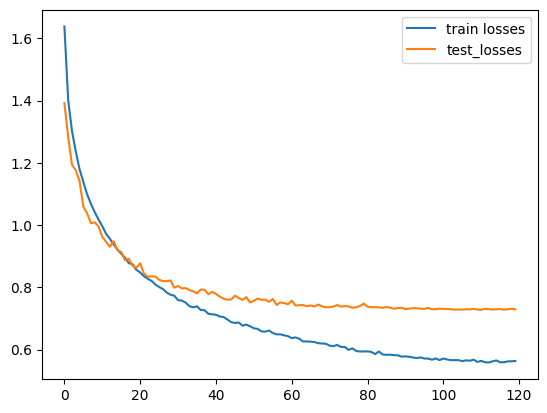

In [16]:
plt.plot(train_losses, label="train losses")
plt.plot(test_losses, label="test_losses")
plt.legend()
plt.show()

## Add 5e-2 L1 Penalty

In [18]:
EPOCHS     = 100
BATCH_SIZE = 128
LR         = 1e-3
WIDTH      = 8
l1_weight  = 2e-5
torch_path = f"best_model_bn_{WIDTH}_{l1_weight}l1.pth"
onnx_path  = f"best_model_bn_{WIDTH}_{l1_weight}l1.onnx"
model      = make_cnn_tiny(3, 32, width=WIDTH, linear_size=256, act_fun=nn.GELU)
state_dict = torch.load(f"best_model_bn_{WIDTH}.pth", weights_only=True)
model.load_state_dict(state_dict)

train_loader, test_loader = get_loaders(batch_size=BATCH_SIZE)

model, train_losses, test_losses = training_loop(model, train_loader, test_loader, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, l1_weight=l1_weight, torch_path=torch_path)

export_onnx(model, onnx_path)

Device: cuda
Parameters: 140,042

L1: 15371.283203125
Epoch   1/100 | train loss 0.948 acc 77.2% | test loss 0.763 acc 74.2% | best 74.2%
L1: 14977.267578125
Epoch   2/100 | train loss 0.943 acc 77.3% | test loss 0.767 acc 74.5% | best 74.5%
L1: 14611.56640625
Epoch   3/100 | train loss 0.939 acc 77.3% | test loss 0.782 acc 73.7% | best 74.5%
L1: 14274.1015625
Epoch   4/100 | train loss 0.935 acc 77.1% | test loss 0.759 acc 74.6% | best 74.6%
L1: 13954.947265625
Epoch   5/100 | train loss 0.924 acc 77.3% | test loss 0.748 acc 74.9% | best 74.9%
L1: 13670.326171875
Epoch   6/100 | train loss 0.924 acc 77.0% | test loss 0.758 acc 74.5% | best 74.9%
L1: 13395.01171875
Epoch   7/100 | train loss 0.919 acc 77.2% | test loss 0.750 acc 74.8% | best 74.9%
L1: 13140.7548828125
Epoch   8/100 | train loss 0.916 acc 77.0% | test loss 0.744 acc 74.4% | best 74.9%
L1: 12905.470703125
Epoch   9/100 | train loss 0.906 acc 77.0% | test loss 0.757 acc 73.9% | best 74.9%
L1: 12686.3515625
Epoch  10/100 |

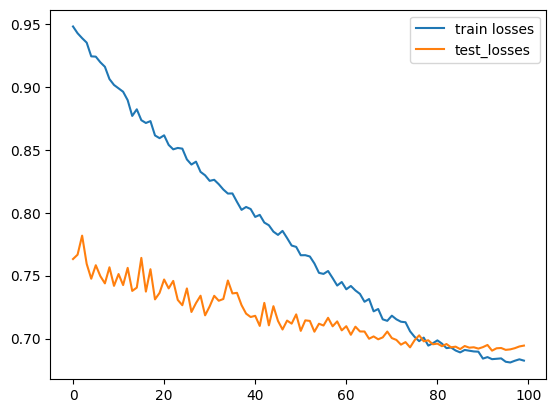

In [19]:
plt.plot(train_losses, label="train losses")
plt.plot(test_losses, label="test_losses")
plt.legend()
plt.show()

## Add 1e-4 L1 Penalty

In [13]:
EPOCHS     = 100
BATCH_SIZE = 128
LR         = 1e-3
WIDTH      = 8
l1_weight  = 1e-4
torch_path = f"best_model_bn_{WIDTH}_{l1_weight}l1.pth"
onnx_path  = f"best_model_bn_{WIDTH}_{l1_weight}l1.onnx"
model      = make_cnn_tiny(3, 32, width=WIDTH, linear_size=256, act_fun=nn.GELU)
state_dict = torch.load(f"best_model_bn_{WIDTH}_{2e-5}l1.pth", weights_only=True)
model.load_state_dict(state_dict)

train_loader, test_loader = get_loaders(batch_size=BATCH_SIZE)

model, train_losses, test_losses = training_loop(model, train_loader, test_loader, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, l1_weight=l1_weight, torch_path=torch_path)

export_onnx(model, onnx_path)

Device: cuda
Parameters: 140,042

L1: 7881.6689453125
Epoch   1/100 | train loss 1.434 acc 78.4% | test loss 0.756 acc 74.6% | best 74.6%
L1: 7279.9033203125
Epoch   2/100 | train loss 1.389 acc 77.7% | test loss 0.733 acc 75.2% | best 75.2%
L1: 6807.92041015625
Epoch   3/100 | train loss 1.350 acc 77.0% | test loss 0.728 acc 75.4% | best 75.4%
L1: 6406.556640625
Epoch   4/100 | train loss 1.317 acc 76.7% | test loss 0.735 acc 75.0% | best 75.4%
L1: 6074.740234375
Epoch   5/100 | train loss 1.292 acc 76.3% | test loss 0.727 acc 75.0% | best 75.4%
L1: 5804.28466796875
Epoch   6/100 | train loss 1.268 acc 76.1% | test loss 0.730 acc 74.8% | best 75.4%
L1: 5564.6787109375
Epoch   7/100 | train loss 1.256 acc 75.9% | test loss 0.720 acc 75.4% | best 75.4%
L1: 5361.064453125
Epoch   8/100 | train loss 1.237 acc 75.6% | test loss 0.722 acc 75.0% | best 75.4%
L1: 5184.5888671875
Epoch   9/100 | train loss 1.226 acc 75.4% | test loss 0.735 acc 74.9% | best 75.4%
L1: 5029.76953125
Epoch  10/100

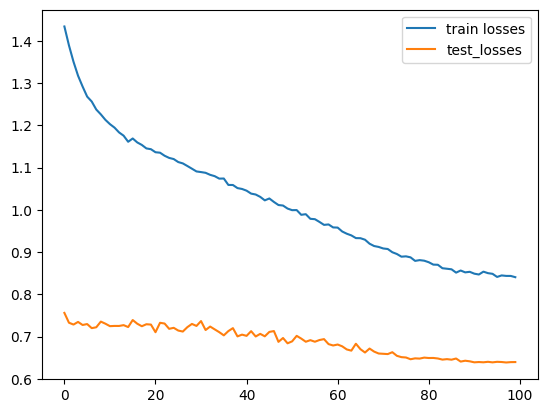

In [14]:
plt.plot(train_losses, label="train losses")
plt.plot(test_losses, label="test_losses")
plt.legend()
plt.show()